In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import statsmodels.api as sm
from scipy.stats import chi2_contingency

# Suppress warnings
warnings.filterwarnings('ignore')

In [ ]:
# To show all columns
pd.set_option('display.max_columns', None)

In [ ]:
# Loading the datasets
train = pd.read_csv(r"/content/drive/MyDrive/Employee attrition dataset/train.csv")
test = pd.read_csv(r"/content/drive/MyDrive/Employee attrition dataset/test.csv")

# Merging both the datasets
df = pd.concat([train, test], ignore_index=True)

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,No,22,Associate Degree,Married,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,No,11,Bachelor’s Degree,Married,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,No,27,High School,Single,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,Yes,71,High School,Divorced,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74498 non-null  int64 
 1   Age                       74498 non-null  int64 
 2   Gender                    74498 non-null  object
 3   Years at Company          74498 non-null  int64 
 4   Job Role                  74498 non-null  object
 5   Monthly Income            74498 non-null  int64 
 6   Work-Life Balance         74498 non-null  object
 7   Job Satisfaction          74498 non-null  object
 8   Performance Rating        74498 non-null  object
 9   Number of Promotions      74498 non-null  int64 
 10  Overtime                  74498 non-null  object
 11  Distance from Home        74498 non-null  int64 
 12  Education Level           74498 non-null  object
 13  Marital Status            74498 non-null  object
 14  Number of Dependents  

In [ ]:
cols = df.columns.tolist()
for col in cols:
    print(f'{col}: has {df[col].nunique()} unique values.')
    print(df[col].unique())
    print("---"*25)

Employee ID: has 74498 unique values.
[ 8410 64756 30257 ... 12409  9554 73042]
---------------------------------------------------------------------------
Age: has 42 unique values.
[31 59 24 36 56 38 47 48 57 30 29 40 19 33 49 51 39 54 23 45 42 53 37 34
 25 41 55 21 28 26 52 50 27 58 43 35 46 44 20 18 22 32]
---------------------------------------------------------------------------
Gender: has 2 unique values.
['Male' 'Female']
---------------------------------------------------------------------------
Years at Company: has 51 unique values.
[19  4 10  7 41  3 23 16 44  1 12  6 38 22 30  9 37 33 13  5 21 32 34 11
  2 18 27 17 36  8 28 35 14 24 40 15 45 39 20 43 26 29 46 42 25 31 47 48
 49 50 51]
---------------------------------------------------------------------------
Job Role: has 5 unique values.
['Education' 'Media' 'Healthcare' 'Technology' 'Finance']
---------------------------------------------------------------------------
Monthly Income: has 9842 unique values.
[ 5390  553

In [ ]:
# Summary statistics of numerical columns
df.describe().drop('Employee ID', axis=1).T

,count,mean,std,min,25%,50%,75%,max
Age,74498.0,38.529746,12.083456,18.0,28.0,39.0,49.0,59.0
Years at Company,74498.0,15.721603,11.223744,1.0,7.0,13.0,23.0,51.0
Monthly Income,74498.0,7299.379514,2152.508566,1226.0,5652.0,7348.0,8876.0,16149.0
Number of Promotions,74498.0,0.832935,0.995289,0.0,0.0,1.0,2.0,4.0
Distance from Home,74498.0,49.991584,28.513611,1.0,25.0,50.0,75.0,99.0
Number of Dependents,74498.0,1.650326,1.553633,0.0,0.0,1.0,3.0,6.0
Company Tenure,74498.0,55.727456,25.399349,2.0,36.0,56.0,76.0,128.0


In [ ]:
# Summary statistics of categorical columns
df.describe(include='object').T

,count,unique,top,freq
Gender,74498,2,Male,40826
Job Role,74498,5,Technology,19322
Work-Life Balance,74498,4,Good,28158
Job Satisfaction,74498,4,High,37245
Performance Rating,74498,4,Average,44719
Overtime,74498,2,No,50157
Education Level,74498,5,Bachelor’s Degree,22331
Marital Status,74498,3,Married,37419
Job Level,74498,3,Entry,29780
Company Size,74498,3,Medium,37231


In [ ]:
df.shape

(74498, 24)

In [ ]:
# Duplicated rows in the dataset
df.duplicated().sum()

0

In [ ]:
df.isnull().sum()

,0
Employee ID,0
Age,0
Gender,0
Years at Company,0
Job Role,0
Monthly Income,0
Work-Life Balance,0
Job Satisfaction,0
Performance Rating,0
Number of Promotions,0


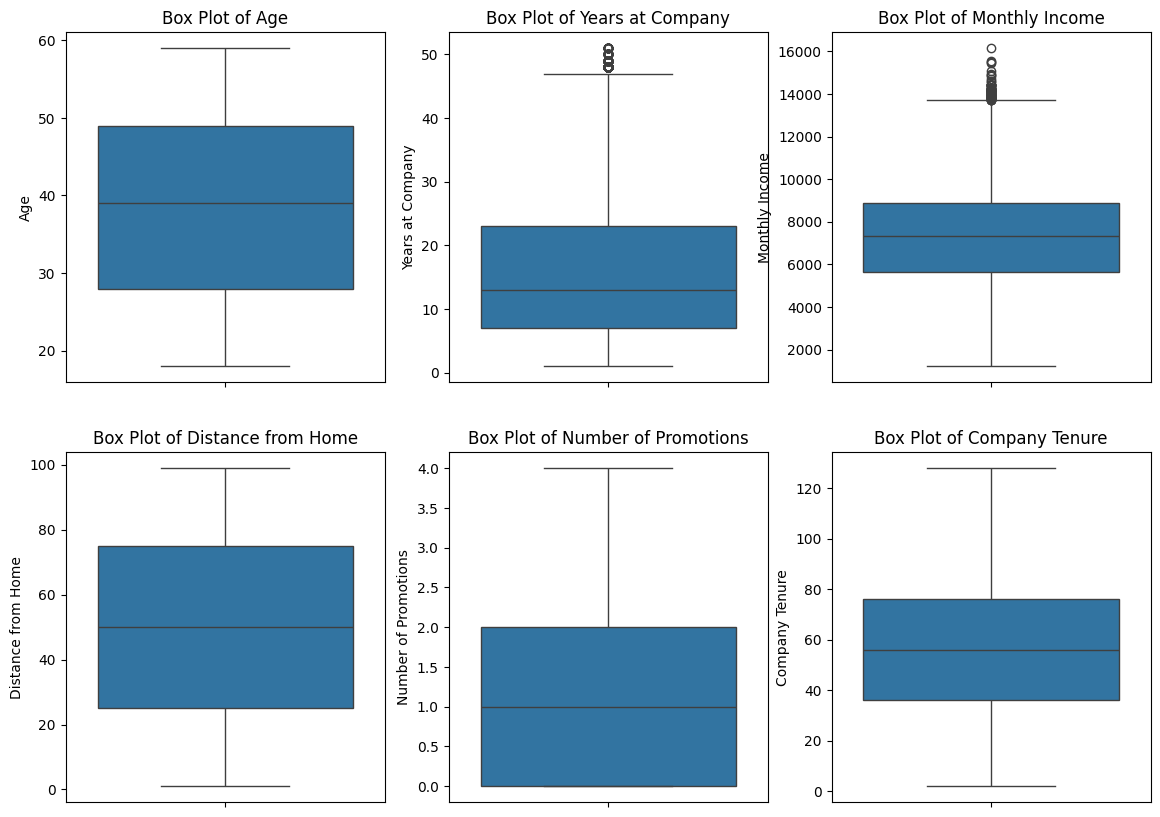

In [ ]:
# List of columns for which to create box plots
numerical_columns = [
    'Age', 'Years at Company', 'Monthly Income', 'Distance from Home',
    'Number of Promotions', 'Company Tenure'
]

# Set up the matplotlib figure with 2 rows and 2 columns for subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# Generate box plots for each column in a separate subplot
for ax, col in zip(axes.flatten(), numerical_columns):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(f'Box Plot of {col}')

# Display the plots
plt.show()

In [ ]:
# All such rows where absolute value of 'Age' - 'Years at Company' is less than 18
df[abs(df['Age'] - df['Years at Company']) < 18].sample(10)

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
30102,67677,24,Female,8,Media,5627,Excellent,High,High,0,No,73,Master’s Degree,Divorced,5,Entry,Medium,53,No,No,No,Good,Very High,Left
15659,37497,54,Male,42,Healthcare,8674,Fair,Low,Average,3,No,27,Bachelor’s Degree,Single,2,Mid,Medium,51,No,No,No,Good,Low,Left
5949,61764,24,Male,16,Technology,6397,Excellent,High,Average,1,No,40,Master’s Degree,Married,0,Entry,Medium,57,No,No,No,Poor,High,Left
15626,49343,32,Female,15,Technology,4925,Fair,High,High,0,No,48,High School,Single,0,Mid,Medium,88,Yes,No,No,Poor,Low,Stayed
38272,21562,19,Female,9,Education,4226,Good,High,Average,0,No,48,Master’s Degree,Divorced,2,Entry,Small,23,No,No,No,Fair,Low,Left
71220,67575,33,Female,21,Technology,11342,Good,High,Average,1,No,96,Associate Degree,Divorced,1,Mid,Small,49,No,No,No,Fair,Low,Stayed
9382,55948,50,Male,35,Healthcare,7438,Fair,Very High,Average,0,Yes,15,Bachelor’s Degree,Single,3,Entry,Medium,96,Yes,No,Yes,Excellent,Low,Left
8219,12400,18,Male,1,Healthcare,9232,Good,High,Average,1,Yes,90,Bachelor’s Degree,Married,1,Senior,Medium,52,No,No,Yes,Good,High,Stayed
45995,23815,21,Male,6,Finance,7708,Good,High,Average,0,No,82,Associate Degree,Single,1,Entry,Medium,12,No,Yes,No,Excellent,Medium,Stayed
4755,2533,21,Male,5,Education,5056,Fair,High,Below Average,1,Yes,35,Associate Degree,Married,1,Mid,Medium,83,No,No,No,Poor,High,Left


In [ ]:
# Count of all such rows
df[abs(df['Age'] - df['Years at Company']) < 18].shape[0]

29812

In [ ]:
# Dropping all such rows
df = df[abs(df['Age'] - df['Years at Company']) >= 18]

In [ ]:
# Dropping the Job Role column
df.drop('Job Role', axis=1, inplace=True)

In [ ]:
df.head()


,Employee ID,Age,Gender,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
1,64756,59,Female,4,5534,Poor,High,Low,3,No,21,Master’s Degree,Divorced,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
3,65791,36,Female,7,3989,Good,High,High,1,No,27,High School,Single,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
5,24368,38,Female,3,9977,Fair,High,Below Average,3,No,37,Bachelor’s Degree,Married,0,Mid,Medium,47,No,No,Yes,Fair,High,Left
6,64970,47,Male,23,3681,Fair,High,High,1,Yes,75,High School,Divorced,3,Entry,Small,93,No,No,No,Good,Medium,Left
7,36999,48,Male,16,11223,Excellent,Very High,High,2,No,5,Master’s Degree,Married,4,Entry,Medium,88,No,No,No,Excellent,Low,Stayed


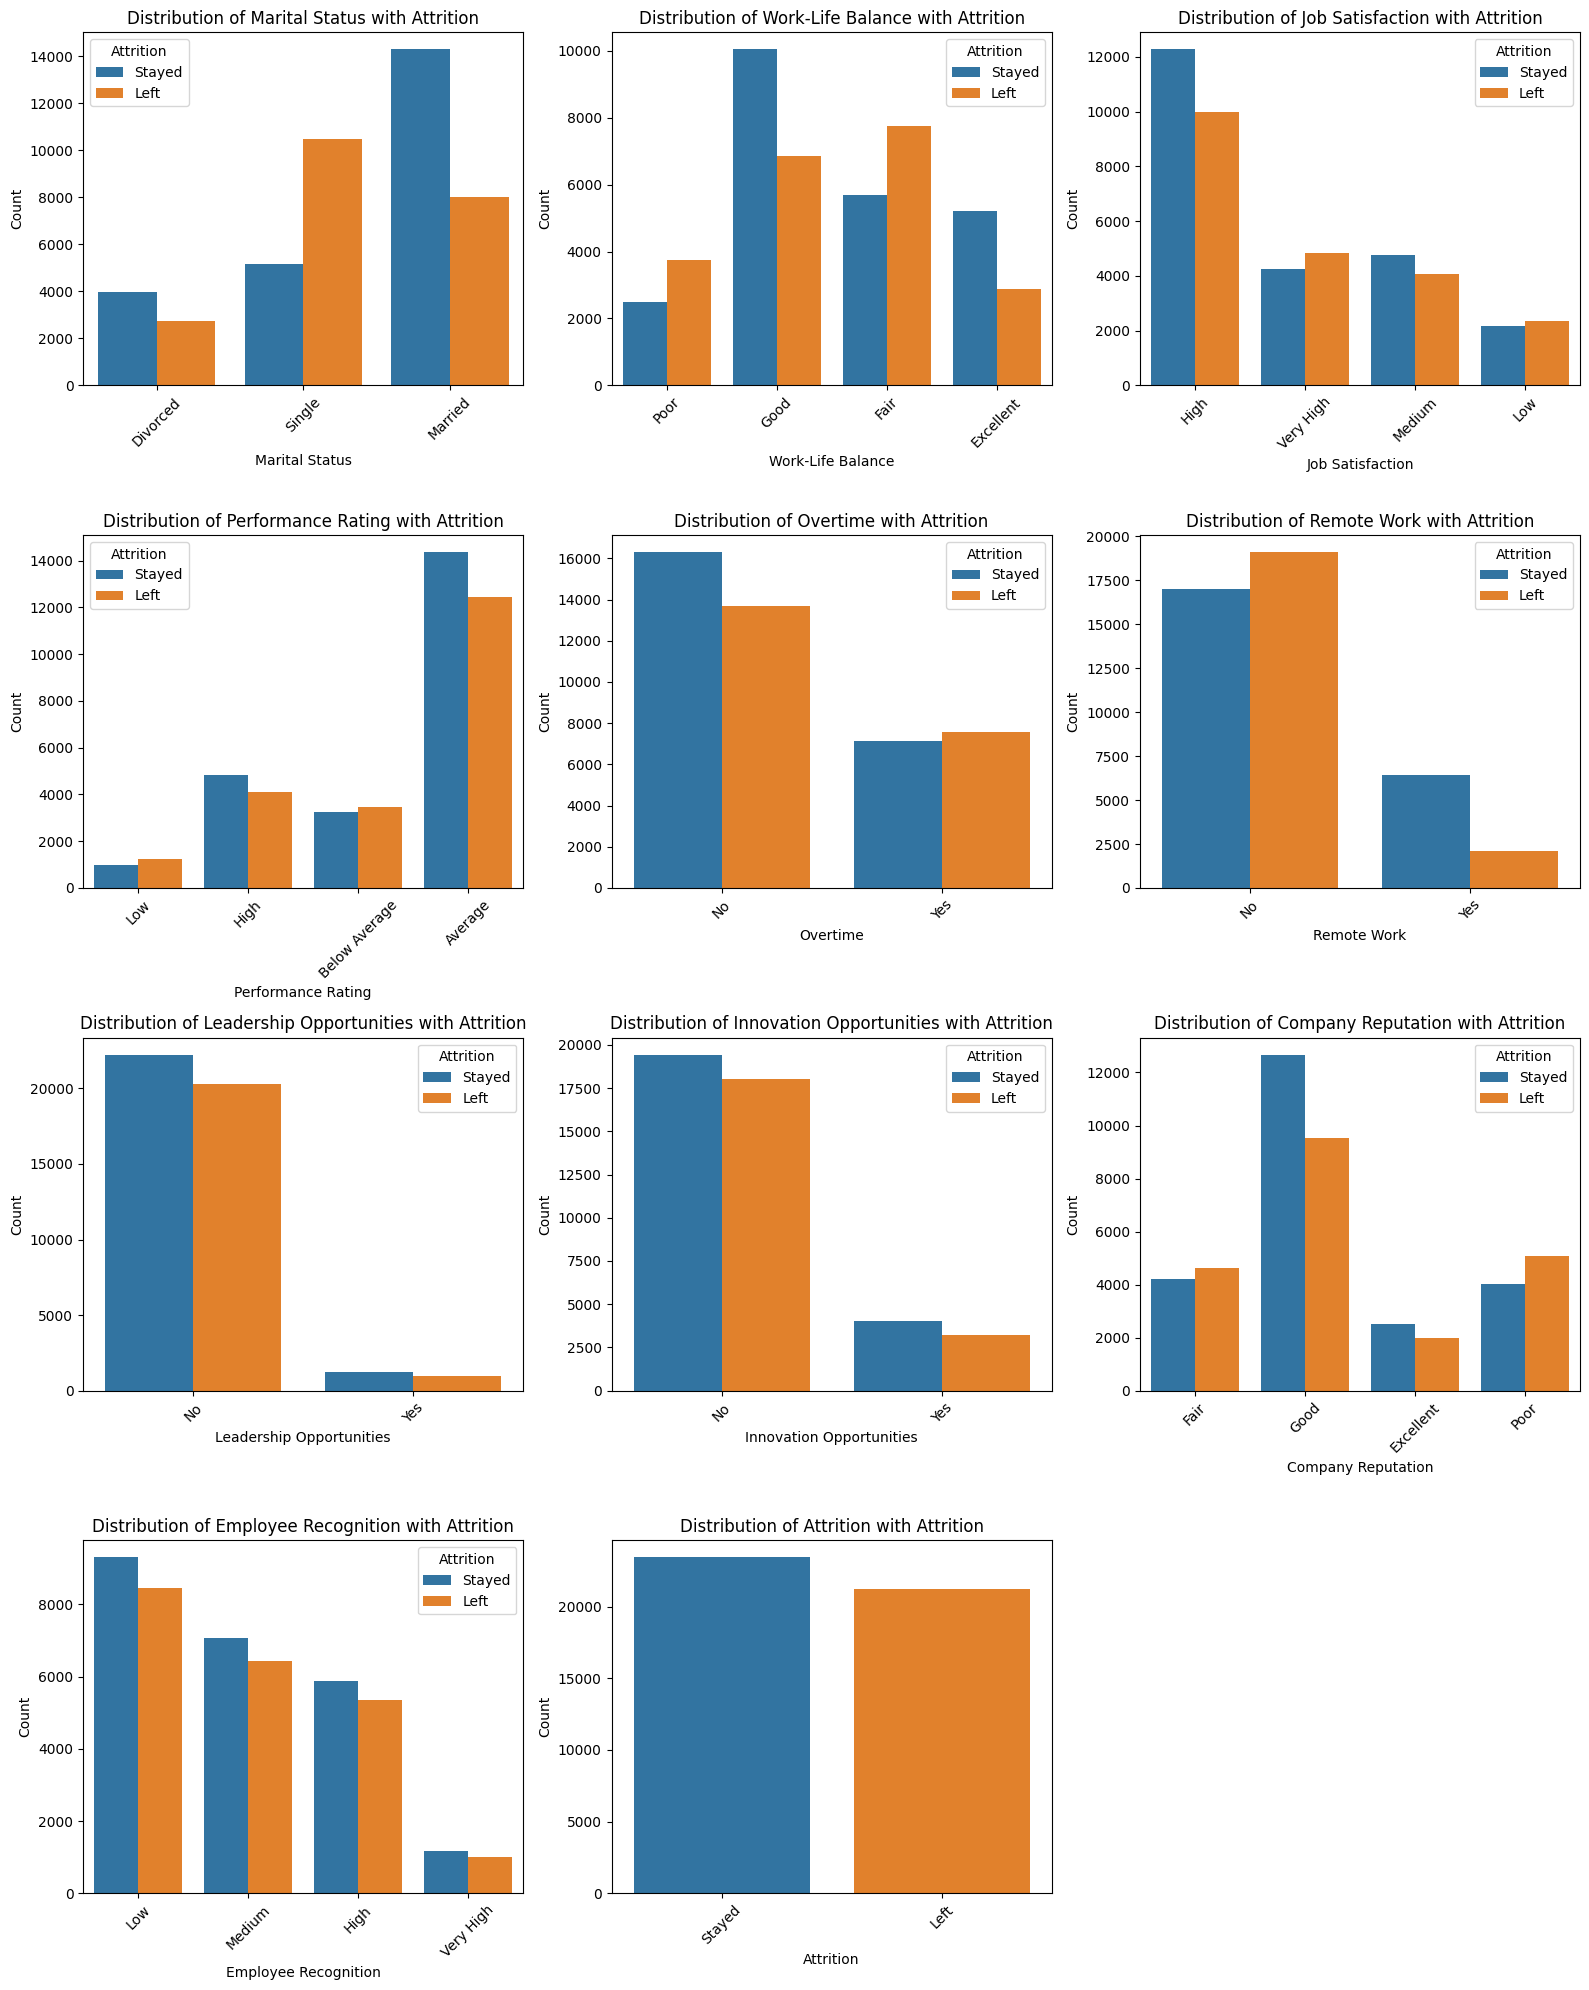

In [ ]:
# List of categorical columns to analyze
categorical_columns = ['Marital Status', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
                       'Overtime', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities',
                       'Company Reputation', 'Employee Recognition', 'Attrition']

plt.figure(figsize=(16, 20))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(4, 3, i)
    sns.countplot(data=df, x=col, hue='Attrition')
    plt.title(f'Distribution of {col} with Attrition')
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()




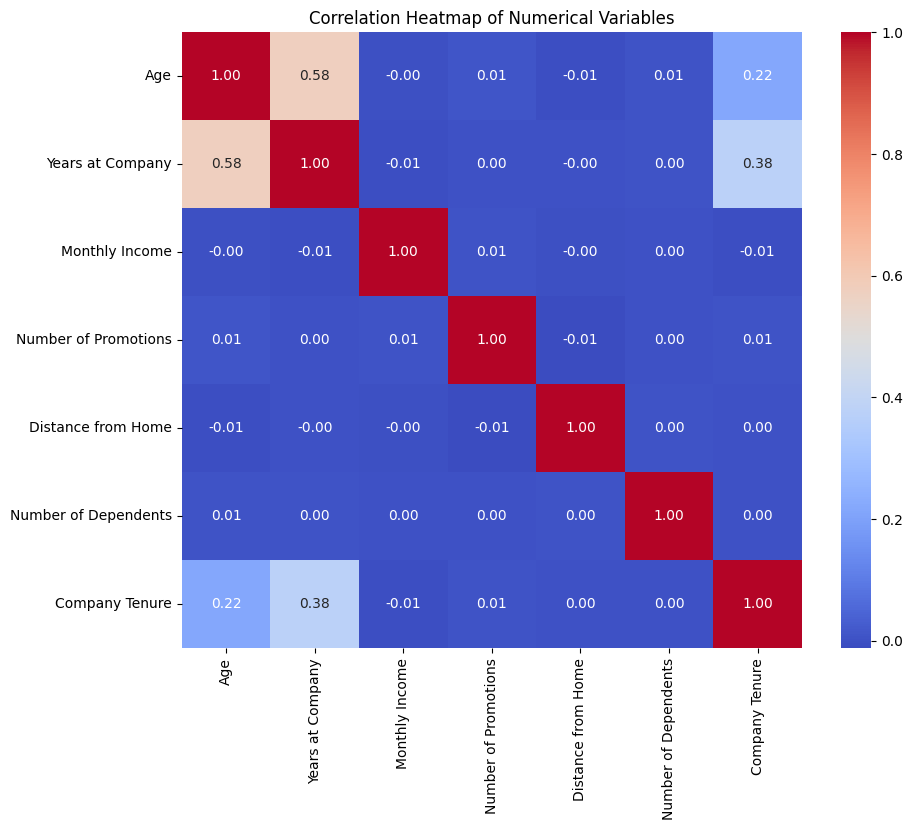

In [ ]:
# List of numerical columns to analyze
numerical_columns = ['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions',
                     'Distance from Home', 'Number of Dependents', 'Company Tenure']

# Heatmap to show correlation between numerical variables
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

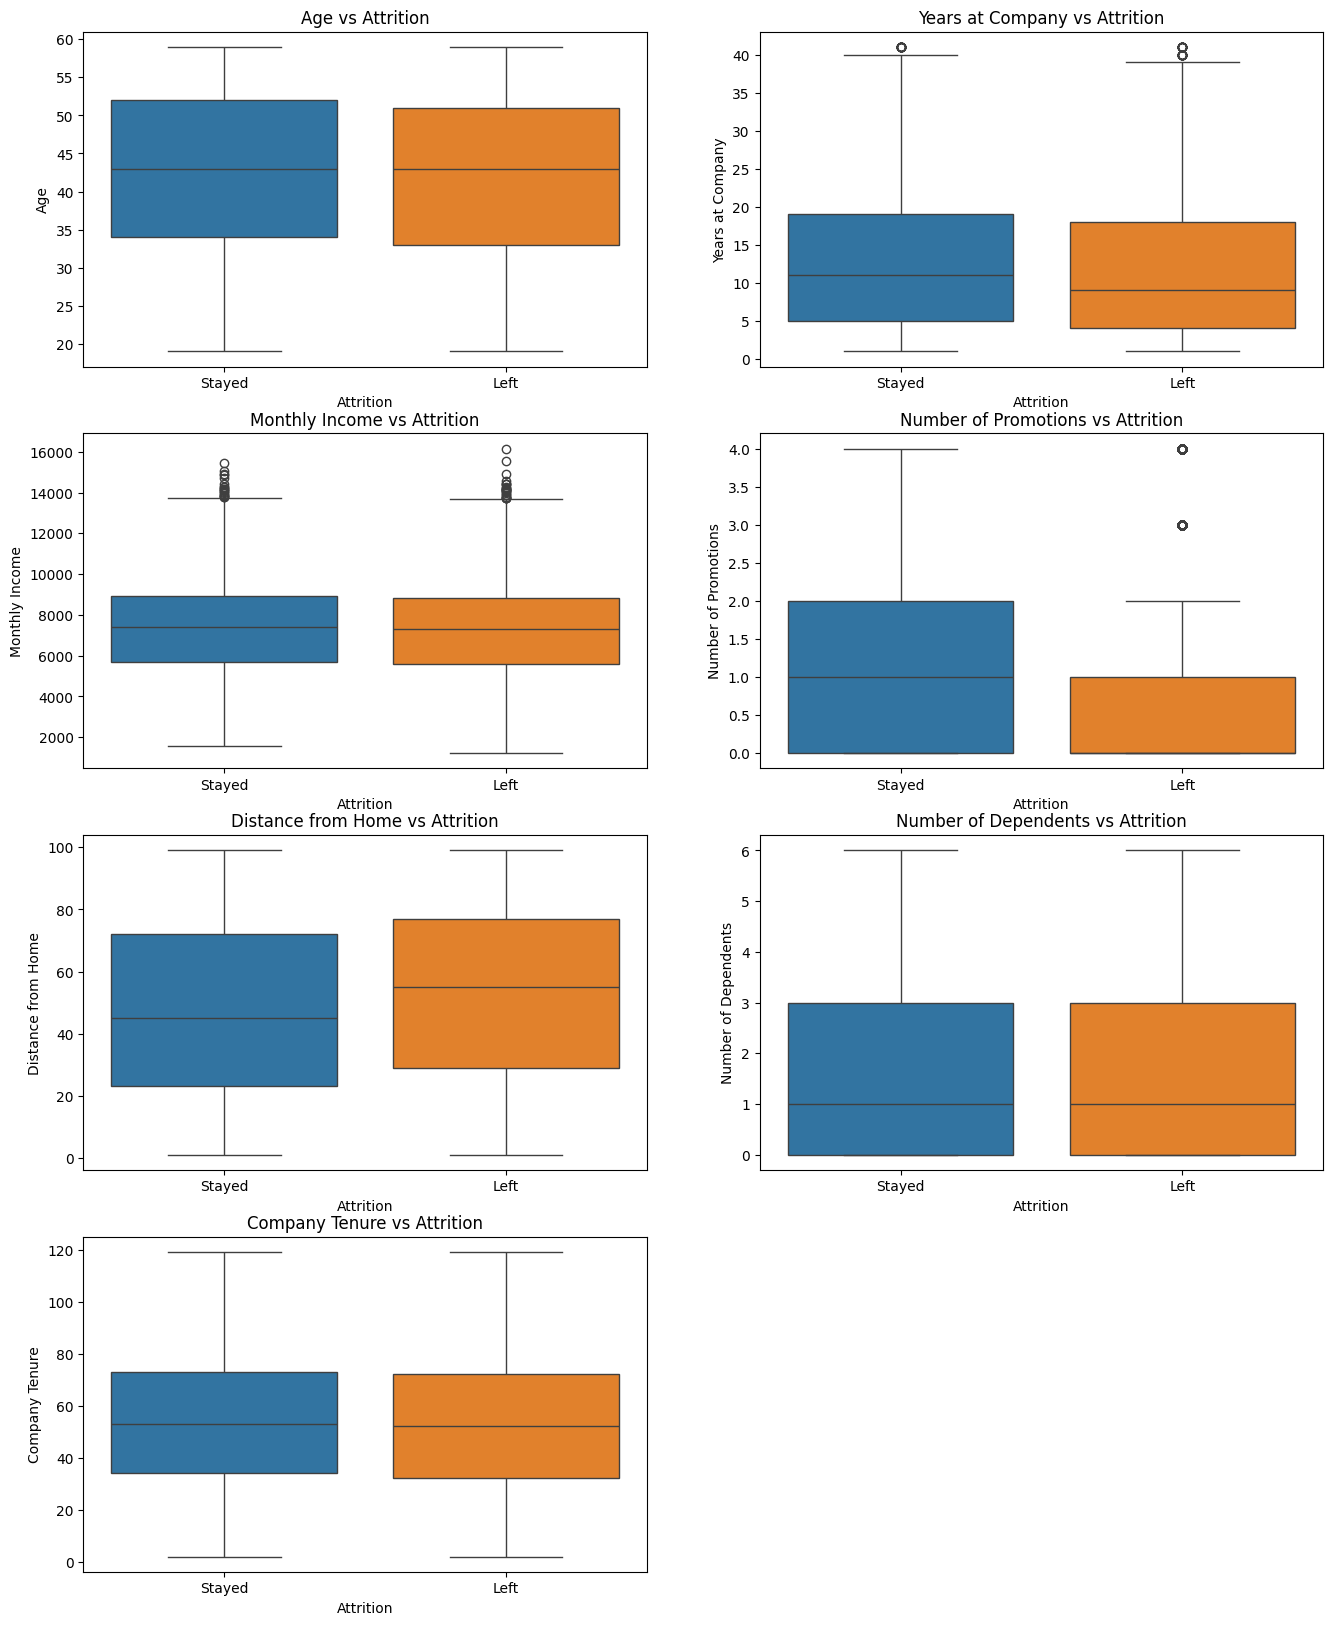

In [ ]:
# Loop through each numerical variable and plot boxplots against Attrition
plt.figure(figsize=(16, 20))
for i,col in enumerate(numerical_columns,1):
  plt.subplot(4,2,i)
  sns.boxplot(x='Attrition', y=col, data=df,hue='Attrition')
  plt.title(f'{col} vs Attrition')

plt.show()




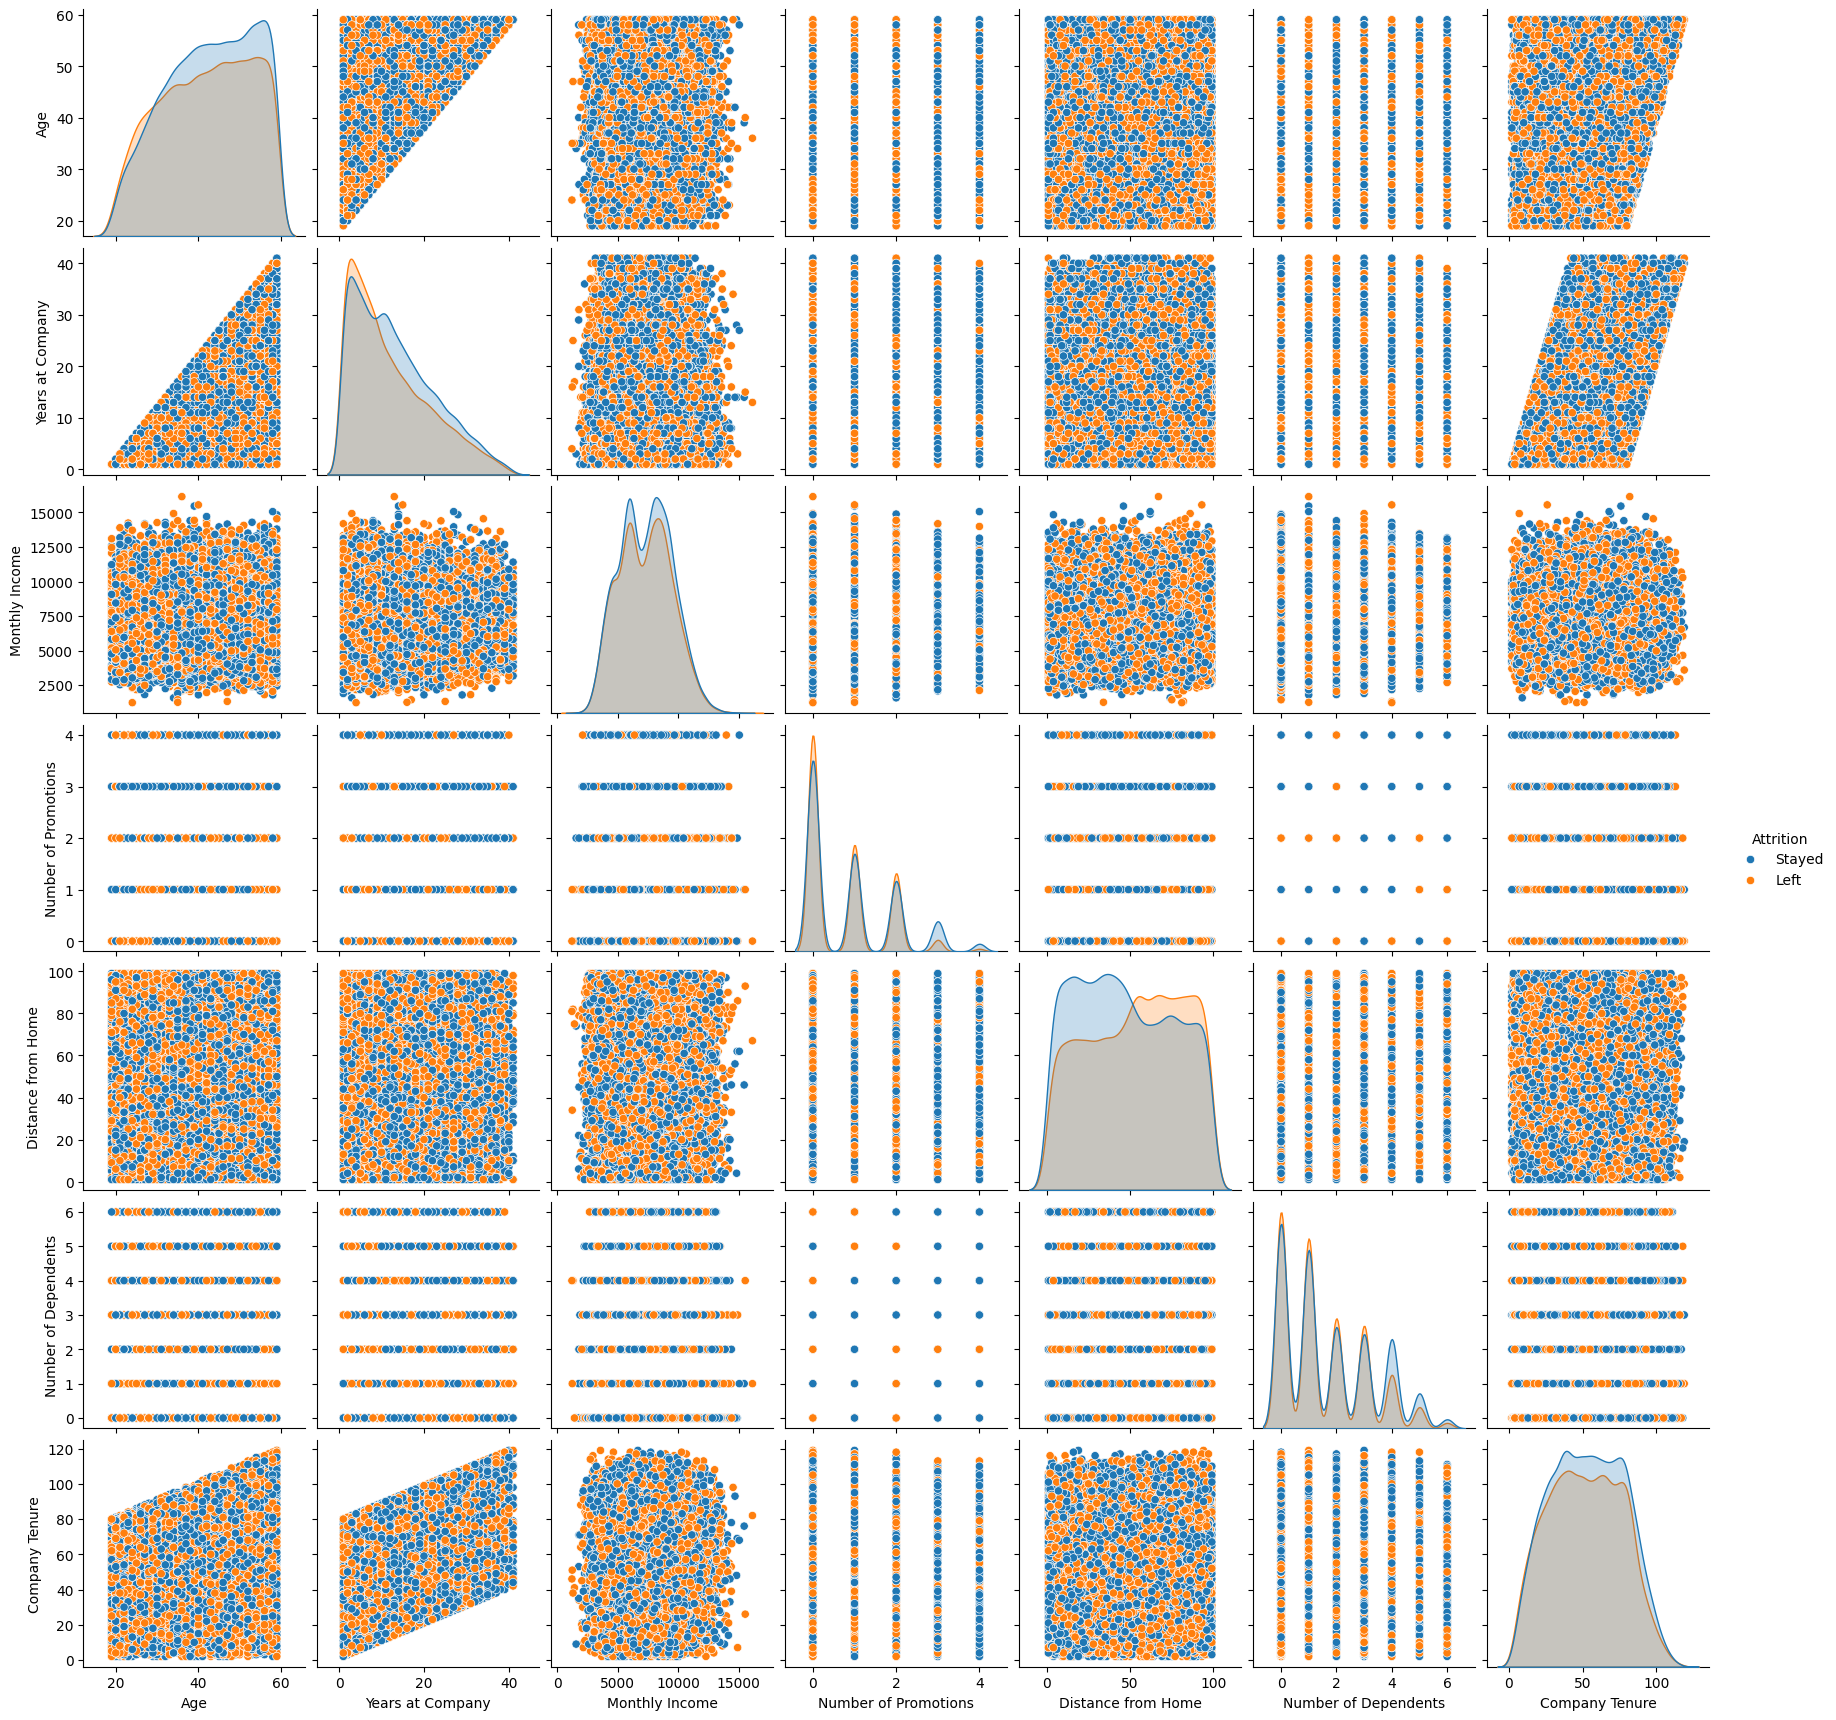

In [ ]:
sns.pairplot(df, hue='Attrition', vars=numerical_columns)
plt.show()

In [ ]:
# Function to calculate Cramér's V
def cramers_v(var1, var2):
    crosstab = pd.crosstab(var1, var2)  # Cross table
    chi2 = chi2_contingency(crosstab)[0]
    n = crosstab.sum().sum()  # Sample size
    r, k = crosstab.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Apply to pairs of categorical columns
categorical_columns = ['Gender', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
                       'Overtime', 'Education Level', 'Marital Status', 'Remote Work',
                       'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation',
                       'Employee Recognition']

cramers_v_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

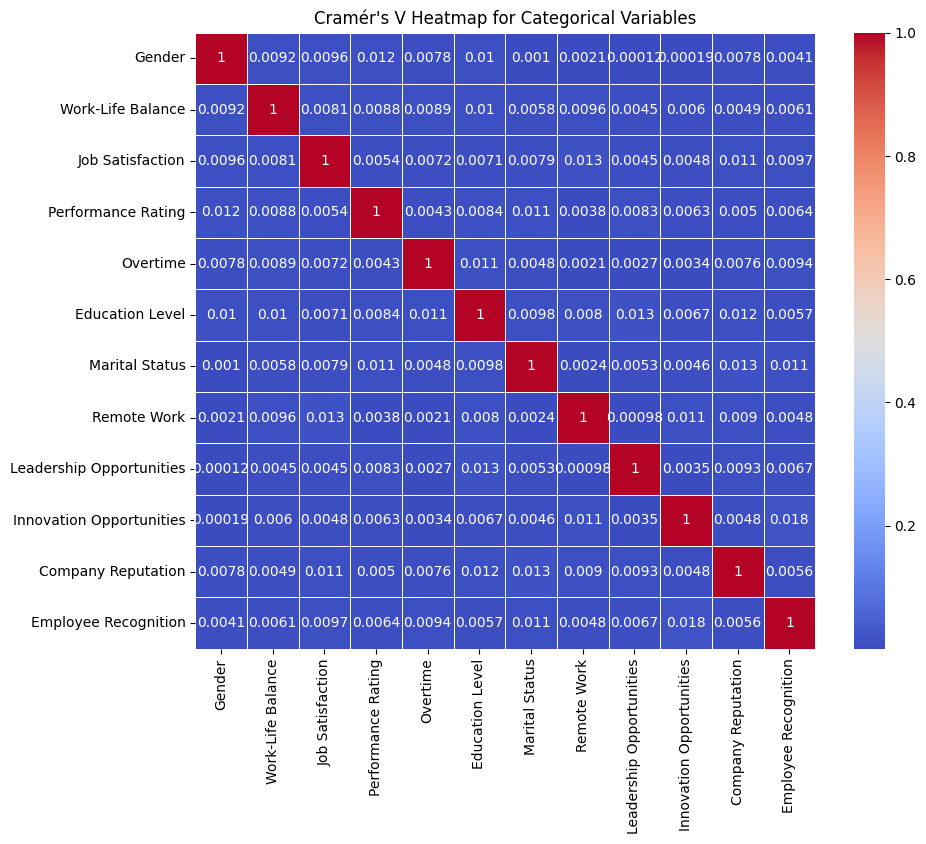

In [ ]:
for col1 in categorical_columns:
    for col2 in categorical_columns:
        cramers_v_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Convert to numeric for a heatmap visualization
cramers_v_matrix = cramers_v_matrix.astype(float)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Cramér\'s V Heatmap for Categorical Variables')
plt.show()

In [ ]:
# Loop through each categorical column and run chi-square test
for col in categorical_columns:
    contingency_table = pd.crosstab(df[col], df['Attrition'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f'{col}: Chi-Square Statistic = {chi2}, p-value = {p}')

Gender: Chi-Square Statistic = 480.9090672111272, p-value = 1.3549805541186008e-106
Work-Life Balance: Chi-Square Statistic = 1755.0775839009605, p-value = 0.0
Job Satisfaction: Chi-Square Statistic = 224.26062352662842, p-value = 2.4080455257450425e-48
Performance Rating: Chi-Square Statistic = 126.74414258468278, p-value = 2.72050811750671e-27
Overtime: Chi-Square Statistic = 136.34511654539483, p-value = 1.6769709095148664e-31
Education Level: Chi-Square Statistic = 532.4531271002018, p-value = 6.3995898503256964e-114
Marital Status: Chi-Square Statistic = 3712.1045773426217, p-value = 0.0
Remote Work: Chi-Square Statistic = 2216.6394911687203, p-value = 0.0
Leadership Opportunities: Chi-Square Statistic = 8.950631397249657, p-value = 0.0027737369896921977
Innovation Opportunities: Chi-Square Statistic = 28.761877462625982, p-value = 8.184642236642496e-08
Company Reputation: Chi-Square Statistic = 528.4329382249655, p-value = 3.2847322263609506e-114
Employee Recognition: Chi-Square 

In [ ]:
# Define the independent variables (numerical columns) and the dependent variable (Attrition)
numerical_columns = ['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']
X = df[numerical_columns]
y = df['Attrition'].apply(lambda x: 1 if x == 'Left' else 0)  # Convert Attrition to 0 and 1

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Print the summary to see p-values and other statistics
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.678671
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                44686
Model:                          Logit   Df Residuals:                    44678
Method:                           MLE   Df Model:                            7
Date:                Wed, 13 Nov 2024   Pseudo R-squ.:                 0.01915
Time:                        05:23:34   Log-Likelihood:                -30327.
converged:                       True   LL-Null:                       -30919.
Covariance Type:            nonrobust   LLR p-value:                2.023e-251
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.1500      0.059      2.564      0.010       0.035       0.265

In [ ]:
# Mapping the ordinal columns
ordinal_mappings = {
    'Work-Life Balance': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Job Satisfaction': {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4},
    'Performance Rating': {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4},
    'Education Level': {'High School': 1, 'Associate Degree': 2, 'Bachelor’s Degree': 3, 'Master’s Degree': 4, 'PhD': 5},
    'Job Level': {'Entry': 1, 'Mid': 2, 'Senior': 3},
    'Company Reputation': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Employee Recognition': {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4},
    'Company Size' : {'Small': 1, 'Medium': 2, 'Large': 3},
}
for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)

In [ ]:
# Mapping the binary columns
binary_columns = ['Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Attrition', 'Overtime', 'Gender']
binary_mapping = {'No': 0, 'Yes': 1, 'Stayed': 0, 'Left': 1, 'Male': 0, 'Female': 1}
for col in binary_columns:
    df[col] = df[col].map(binary_mapping)

In [ ]:
# Creating dummy variables for Marital Status
df = pd.get_dummies(df, columns=['Marital Status'], drop_first=True)

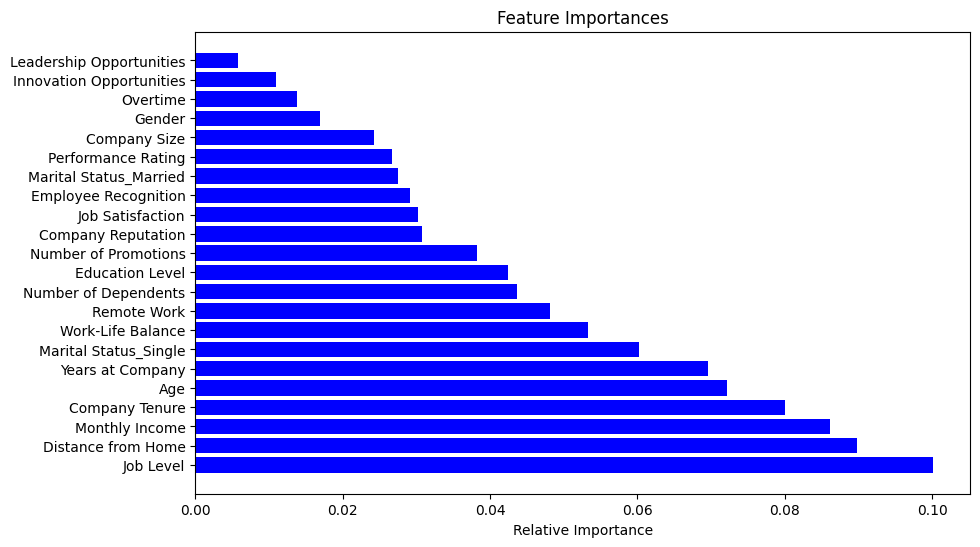

Age: 0.07217493528759139
Gender: 0.016908986780091017
Years at Company: 0.06963068642784502
Monthly Income: 0.08607933545769468
Work-Life Balance: 0.0533555660382063
Job Satisfaction: 0.03024735202390817
Performance Rating: 0.02663964910422432
Number of Promotions: 0.03818578475631075
Overtime: 0.013814033781880385
Distance from Home: 0.08979037571898307
Education Level: 0.042482181070277604
Number of Dependents: 0.0436392190409021
Job Level: 0.10013805910371082
Company Size: 0.024284386461646053
Company Tenure: 0.08007897304652048
Remote Work: 0.04812943050095461
Leadership Opportunities: 0.005842177665547354
Innovation Opportunities: 0.010996270675698144
Company Reputation: 0.030754673464971998
Employee Recognition: 0.02913981110043722
Marital Status_Married: 0.027498655149328092
Marital Status_Single: 0.06018945734327025


In [ ]:
#finding important features
X = df.drop(['Employee ID', 'Attrition'], axis=1)
y = df['Attrition']

# Fitting using Random Forest Classifier
rf = RandomForestClassifier()
rf.fit(X, y)

# Get feature importances
importances = rf.feature_importances_

# Sort feature importances in descending order
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importances')
plt.show()

# Print feature importances
for i, feature in enumerate(X.columns):
    print(f"{feature}: {importances[i]}")

In [ ]:
# Define your features (X) and target (y)
X = df.drop(columns=['Attrition'])  # All columns except the target
y = df['Attrition']  # The target column

# Split the dataset into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the resulting datasets
print(f'Training data shape: {X_train.shape}, {y_train.shape}')
print(f'Testing data shape: {X_test.shape}, {y_test.shape}')

Training data shape: (35748, 23), (35748,)
Testing data shape: (8938, 23), (8938,)


In [ ]:
df.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Monthly Income',
       'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
       'Number of Promotions', 'Overtime', 'Distance from Home',
       'Education Level', 'Number of Dependents', 'Job Level', 'Company Size',
       'Company Tenure', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition', 'Marital Status_Married',
       'Marital Status_Single'],
      dtype='object')

In [ ]:
selected_features = [
    'Gender',                    # Significant impact on retention
    'Work-Life Balance',         # Directly influences job satisfaction and attrition
    'Job Satisfaction',          # Higher satisfaction correlates with lower attrition
    'Performance Rating',        # High performers tend to stay longer
    'Overtime',                  # Balance with compensation influences satisfaction
    'Education Level',           # Certain levels may indicate mobility
    'Remote Work',               # Flexible work conditions improve satisfaction
    'Company Reputation',        # Company image affects employee decisions
    'Years at Company',          # Longer tenure decreases likelihood of leaving
    'Number of Promotions',      # More promotions correlate with higher retention
    'Distance from Home',        # Commuting issues impact employee decisions
    'Number of Dependents',      # More dependents may lead to job stability desire
    'Marital Status_Single',     # Dummy variable for marital status (1: Single)
    'Marital Status_Married',    # Dummy variable for marital status (1: Married)
]

# Prepare the training data with selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Check the shape of the selected feature set
print(f'Selected training data shape: {X_train_selected.shape}')
print(f'Selected testing data shape: {X_test_selected.shape}')

Selected training data shape: (35748, 14)
Selected testing data shape: (8938, 14)


In [ ]:
# Scale the selected features
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)

In [ ]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
}

# Store metrics for each model
model_metrics = {}

# Train and evaluate models
for name, model in models.items():
    # Fit the model
    model.fit(X_train_selected_scaled, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test_selected_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Store metrics in a dictionary
    model_metrics[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Confusion Matrix': cm
    }

    # Print metrics
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    print(f"Confusion Matrix:\n{cm}\n")

# Convert model metrics to DataFrame for better visualization
metrics_df = pd.DataFrame(model_metrics).T
print(metrics_df)

Logistic Regression - Accuracy: 0.7014, Precision: 0.7008, Recall: 0.6585
Confusion Matrix:
[[3446 1205]
 [1464 2823]]

LDA - Accuracy: 0.7019, Precision: 0.7032, Recall: 0.6550
Confusion Matrix:
[[3466 1185]
 [1479 2808]]

QDA - Accuracy: 0.6924, Precision: 0.6776, Recall: 0.6844
Confusion Matrix:
[[3255 1396]
 [1353 2934]]

Decision Tree - Accuracy: 0.6175, Precision: 0.6042, Recall: 0.5869
Confusion Matrix:
[[3003 1648]
 [1771 2516]]

Random Forest - Accuracy: 0.7017, Precision: 0.7041, Recall: 0.6522
Confusion Matrix:
[[3476 1175]
 [1491 2796]]

                     Accuracy Precision    Recall  \
Logistic Regression  0.701387  0.700844  0.658502   
LDA                  0.701947  0.703231  0.655003   
QDA                  0.692437  0.677598  0.684395   
Decision Tree        0.617476  0.604227  0.586891   
Random Forest        0.701723  0.704105  0.652204   

                                 Confusion Matrix  
Logistic Regression  [[3446, 1205], [1464, 2823]]  
LDA                  

In [ ]:
# Define the model
qda = QuadraticDiscriminantAnalysis()

# Define the hyperparameters and their values for tuning
param_grid = {
    'reg_param': [0.0, 0.1, 0.5, 1.0],  # Regularization parameter
    'priors': [None, [0.5, 0.5], [0.7, 0.3]]  # Prior probabilities for each class
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=qda, param_grid=param_grid,
                           scoring='recall',  # Focus on maximizing recall
                           cv=5,  # 5-fold cross-validation
                           verbose=1,
                           n_jobs=-1)  # Use all available cores

# Fit the model using the training data
grid_search.fit(X_train_selected_scaled, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Recall Score: {best_score:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'priors': [0.5, 0.5], 'reg_param': 0.1}
Best Recall Score: 0.7220


In [ ]:
# Initialize the QDA model with the best parameters
best_qda_model = QuadraticDiscriminantAnalysis(priors=best_params['priors'], reg_param=best_params['reg_param'])

# Fit the model to the training data
best_qda_model.fit(X_train_selected_scaled, y_train)

QuadraticDiscriminantAnalysis(priors=[0.5, 0.5], reg_param=0.1)

In [ ]:
# Predict on the test set
y_pred_best = best_qda_model.predict(X_test_selected_scaled)

# Print the predicted values
print("Predictions on test data:", y_pred_best)

Predictions on test data: [0 0 1 ... 1 0 1]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Calculate metrics
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
confusion_matrix_best = confusion_matrix(y_test, y_pred_best)

# Print the evaluation results
print(f"Best QDA Model - Accuracy: {accuracy_best:.4f}")
print(f"Best QDA Model - Precision: {precision_best:.4f}")
print(f"Best QDA Model - Recall: {recall_best:.4f}")
print(f"Best QDA Model - Confusion Matrix:\n{confusion_matrix_best}\n")

Best QDA Model - Accuracy: 0.6934
Best QDA Model - Precision: 0.6665
Best QDA Model - Recall: 0.7222
Best QDA Model - Confusion Matrix:
[[3102 1549]
 [1191 3096]]



In [ ]:
drive_model_path = '/content/drive/My Drive/qda_attrition_model.pkl'
joblib.dump(best_qda_model, drive_model_path)
print("Trained QDA model also saved successfully to Google Drive.")

Trained QDA model also saved successfully to Google Drive.


In [ ]:
import pandas as pd
import joblib

# Load the saved model
model = joblib.load(r'/content/drive/MyDrive/qda_attrition_model.pkl')

def predict_employee_attrition(file_path):
    # Load the input CSV file
    input_data = pd.read_csv(r'/content/drive/MyDrive/Employee attrition dataset/test.csv')

    # Preprocess the input data similar to the training data
    ordinal_mappings = {
        'Work-Life Balance': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
        'Job Satisfaction': {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4},
        'Performance Rating': {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4},
        'Education Level': {'High School': 1, 'Associate Degree': 2, 'Bachelor’s Degree': 3, 'Master’s Degree': 4, 'PhD': 5},
        'Job Level': {'Entry': 1, 'Mid': 2, 'Senior': 3},
        'Company Reputation': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
        'Employee Recognition': {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4},
    }

    for col, mapping in ordinal_mappings.items():
        input_data[col] = input_data[col].map(mapping)
    # Binary encoding for binary columns
    binary_columns = ['Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Overtime', 'Gender']
    binary_mapping = {'No': 0, 'Yes': 1, 'Male': 0, 'Female': 1}

    for col in binary_columns:
        input_data[col] = input_data[col].map(binary_mapping)

    # Creating dummy variables for Marital Status
    input_data = pd.get_dummies(input_data, columns=['Marital Status'], drop_first=True)

    # Ensure the input data has the same features as the model was trained on
    selected_features = [
        'Gender', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating',
        'Overtime', 'Education Level', 'Remote Work', 'Company Reputation',
        'Years at Company', 'Number of Promotions', 'Distance from Home',
        'Number of Dependents', 'Marital Status_Single', 'Marital Status_Married'
    ]

    # Ensure all selected features are present in the input data
    for feature in selected_features:
        if feature not in input_data.columns:
            input_data[feature] = 0  # Add missing columns with default value

    # Make predictions
    predictions = model.predict(input_data[selected_features])
    # Add predictions to the DataFrame
    input_data['Attrition Prediction'] = predictions

    # Calculating the Annual Income
    input_data['Annual Income'] = input_data['Monthly Income'] * 12
    # Calculate Replacement Cost
    input_data['Replacement Cost'] = (input_data['Monthly Income'] * 12) * 0.33


    # Decoding the predicted values back to original labels
    input_data['Attrition Prediction'] = input_data['Attrition Prediction'].map({0: 'Stayed', 1: 'Left'})
    input_data['Work-Life Balance'] = input_data['Work-Life Balance'].map({1: 'Poor', 2: 'Fair', 3: 'Good', 4: 'Excellent'})
    input_data['Job Satisfaction'] = input_data['Job Satisfaction'].map({1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'})
    input_data['Performance Rating'] = input_data['Performance Rating'].map({1: 'Low', 2: 'Below Average', 3: 'Average', 4: 'High'})
    input_data['Education Level'] = input_data['Education Level'].map({1: 'High School', 2: 'Associate Degree', 3: 'Bachelor’s Degree', 4: 'Master’s Degree', 5: 'PhD'})
    input_data['Job Level'] = input_data['Job Level'].map({1: 'Entry', 2: 'Mid', 3: 'Senior'})
    input_data['Company Reputation'] = input_data['Company Reputation'].map({1: 'Poor', 2: 'Fair', 3: 'Good', 4: 'Excellent'})
    input_data['Employee Recognition'] = input_data['Employee Recognition'].map({1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'})
    # Return rows where attrition is predicted
    at_risk_employees = input_data[input_data['Attrition Prediction'] == 'Left']
    return at_risk_employees

# Example usage:
predictions = predict_employee_attrition('test.csv')
predictions.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition,Marital Status_Married,Marital Status_Single,Attrition Prediction,Annual Income,Replacement Cost
1243,70428,29,1,2,Education,4004,Poor,Medium,Average,0,0,19,Bachelor’s Degree,1,Mid,Medium,19,0,0,0,Good,Low,Left,False,True,Left,48048,15855.84
1755,57473,45,0,1,Technology,8400,Poor,High,Average,0,0,32,High School,0,Mid,Small,8,0,0,0,Good,High,Left,False,True,Left,100800,33264.00
1800,14770,24,1,4,Technology,12143,Fair,High,Average,1,0,4,High School,0,Mid,Medium,12,0,0,0,Good,Medium,Stayed,False,True,Left,145716,48086.28
2468,22573,50,1,1,Technology,6218,Fair,Very High,Average,0,0,15,Bachelor’s Degree,1,Senior,Large,32,0,0,0,Good,Low,Left,False,False,Left,74616,24623.28
2918,73203,59,1,1,Education,3976,Poor,High,Below Average,0,0,15,Bachelor’s Degree,1,Senior,Large,66,0,1,0,Good,Medium,Stayed,False,True,Left,47712,15744.96


In [ ]:
predictions.head(40)

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition,Marital Status_Married,Marital Status_Single,Attrition Prediction,Annual Income,Replacement Cost
1243,70428,29,1,2,Education,4004,Poor,Medium,Average,0,0,19,Bachelor’s Degree,1,Mid,Medium,19,0,0,0,Good,Low,Left,False,True,Left,48048,15855.84
1755,57473,45,0,1,Technology,8400,Poor,High,Average,0,0,32,High School,0,Mid,Small,8,0,0,0,Good,High,Left,False,True,Left,100800,33264.00
1800,14770,24,1,4,Technology,12143,Fair,High,Average,1,0,4,High School,0,Mid,Medium,12,0,0,0,Good,Medium,Stayed,False,True,Left,145716,48086.28
2468,22573,50,1,1,Technology,6218,Fair,Very High,Average,0,0,15,Bachelor’s Degree,1,Senior,Large,32,0,0,0,Good,Low,Left,False,False,Left,74616,24623.28
2918,73203,59,1,1,Education,3976,Poor,High,Below Average,0,0,15,Bachelor’s Degree,1,Senior,Large,66,0,1,0,Good,Medium,Stayed,False,True,Left,47712,15744.96
4073,633,58,0,1,Healthcare,8892,Poor,Low,High,0,0,14,Associate Degree,0,Entry,Large,9,0,1,0,Good,High,Stayed,True,False,Left,106704,35212.32
4264,45689,52,0,1,Finance,13109,Fair,Very High,Average,0,1,31,Associate Degree,0,Senior,Medium,67,0,0,0,Good,Medium,Stayed,False,True,Left,157308,51911.64
5017,31275,20,1,2,Education,4074,Poor,Low,Average,0,1,4,High School,1,Mid,Small,4,1,0,0,Excellent,Low,Left,False,True,Left,48888,16133.04
5998,20110,25,0,1,Media,6520,Fair,High,Average,1,1,22,High School,1,Entry,Medium,47,1,0,0,Excellent,High,Stayed,False,True,Left,78240,25819.20
6090,54393,21,1,1,Education,3702,Fair,High,Average,1,0,26,High School,1,Entry,Large,5,0,0,0,Good,High,Left,False,False,Left,44424,14659.92


In [ ]:
# Filtering based on business choice
predictions[predictions['Replacement Cost'] > 50000]

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition,Marital Status_Married,Marital Status_Single,Attrition Prediction,Annual Income,Replacement Cost
4264,45689,52,0,1,Finance,13109,Fair,Very High,Average,0,1,31,Associate Degree,0,Senior,Medium,67,0,0,0,Good,Medium,Stayed,False,True,Left,157308,51911.64


In [ ]:
seed = 0   # We set our random seed to zero for reproducibility
# Random Forest parameters
rf_params = {
    'n_jobs': -1,
    'n_estimators': 1000,
#     'warm_start': True,
    'max_features': 0.3,
    'max_depth': 4,
    'min_samples_leaf': 2,
    'max_features' : 'sqrt',
    'random_state' : seed,
    'verbose': 0
}

In [ ]:
rf = RandomForestClassifier(**rf_params)

In [ ]:
rf.fit(X_train_selected_scaled, y_train)
print("Fitting of Random Forest finished")

Fitting of Random Forest finished


In [ ]:

rf_predictions = rf.predict(X_test_selected_scaled)
print("Predictions finished")

Predictions finished


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy score: {}".format(accuracy_score(y_test, rf_predictions)))
print("="*80)
print(classification_report(y_test, rf_predictions))

Accuracy score: 0.6924367867531886
              precision    recall  f1-score   support

           0       0.68      0.78      0.73      4651
           1       0.72      0.60      0.65      4287

    accuracy                           0.69      8938
   macro avg       0.70      0.69      0.69      8938
weighted avg       0.70      0.69      0.69      8938

